# Plots

In [95]:
output_folder_path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\picturesForThesis\\plots"

## Pinhole Plot

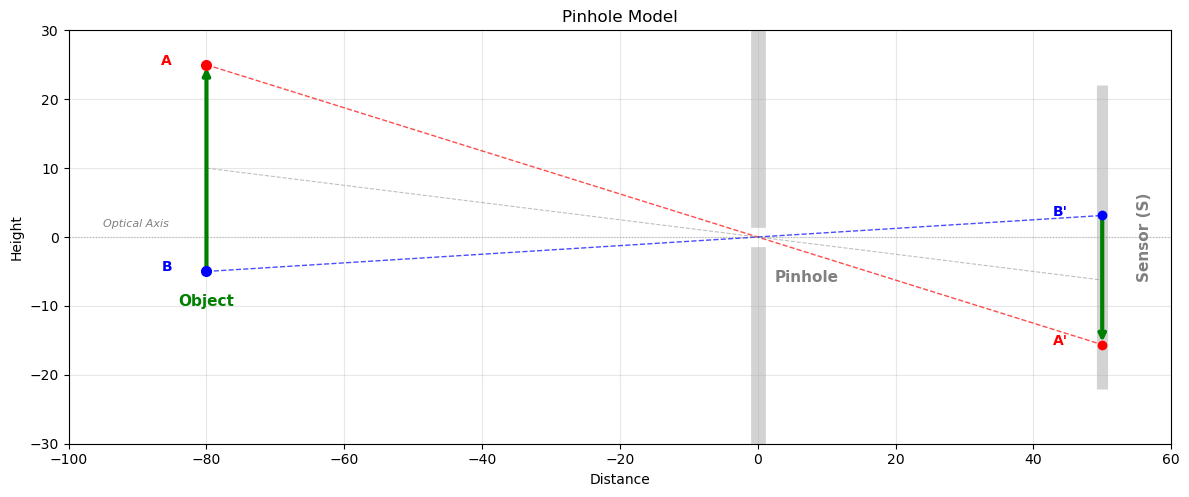

In [96]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_pinhole_camera():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    object_x, pinhole_x, sensor_x = -80, 0, 50
    object_height, object_base_y = 30, -5
    pinhole_radius, barrier_height = 1.5, 45
    
    arrow_tip_y = object_base_y + object_height
    arrow_base_y = object_base_y
    
    ax.annotate('', xy=(object_x, arrow_tip_y), xytext=(object_x, arrow_base_y),
                arrowprops=dict(arrowstyle='->', color='green', lw=3))
    ax.plot([object_x], [arrow_base_y], 'o', color='green', markersize=6)
    ax.text(object_x, arrow_base_y - 5, 'Object', ha='center', fontsize=11, fontweight='bold', color='green')
    
    ax.plot(object_x, arrow_tip_y, 'o', color='red', markersize=7, zorder=5)
    ax.plot(object_x, arrow_base_y, 'o', color='blue', markersize=7, zorder=5)
    ax.text(object_x - 5, arrow_tip_y, 'A', fontsize=10, ha='right', color='red', fontweight='bold')
    ax.text(object_x - 5, arrow_base_y, 'B', fontsize=10, ha='right', color='blue', fontweight='bold')
    
    ax.add_patch(patches.Rectangle((pinhole_x - 1, pinhole_radius), 2, barrier_height - pinhole_radius,
                                    linewidth=0.5, edgecolor='lightgray', facecolor='lightgray'))
    ax.add_patch(patches.Rectangle((pinhole_x - 1, -barrier_height), 2, barrier_height - pinhole_radius,
                                    linewidth=0.5, edgecolor='lightgray', facecolor='lightgray'))
    ax.text(pinhole_x + 2.5, -pinhole_radius - 5, 'Pinhole', ha='left', fontsize=11, fontweight='bold', color='gray')
    
    ax.plot([sensor_x, sensor_x], [-22, 22], color='lightgray', linewidth=8, solid_capstyle='butt', zorder=1)
    ax.text(sensor_x + 5, 0, 'Sensor (S)', fontsize=11, fontweight='bold', color='gray', va='center', rotation=90)
    
    magnification = abs(sensor_x - pinhole_x) / abs(object_x - pinhole_x)
    image_tip_y = -arrow_tip_y * magnification
    image_base_y = -arrow_base_y * magnification
    
    ax.plot([object_x, pinhole_x, sensor_x], [arrow_tip_y, 0, image_tip_y], 'r--', linewidth=1, alpha=0.7)
    ax.plot([object_x, pinhole_x, sensor_x], [arrow_base_y, 0, image_base_y], 'b--', linewidth=1, alpha=0.7)
    mid_y = (arrow_tip_y + arrow_base_y) / 2
    ax.plot([object_x, pinhole_x, sensor_x], [mid_y, 0, -mid_y * magnification], 'gray', linewidth=0.8, alpha=0.5, linestyle='--')
    
    ax.annotate('', xy=(sensor_x, image_tip_y), xytext=(sensor_x, image_base_y),
                arrowprops=dict(arrowstyle='->', color='green', lw=3), zorder=10)
    ax.plot([sensor_x], [image_base_y], 'o', color='green', markersize=5, zorder=10)
    ax.plot(sensor_x, image_tip_y, 'o', color='red', markersize=6, zorder=10)
    ax.plot(sensor_x, image_base_y, 'o', color='blue', markersize=6, zorder=10)
    ax.text(sensor_x - 5, image_tip_y, "A'", fontsize=10, ha='right', color='red', fontweight='bold')
    ax.text(sensor_x - 5, image_base_y, "B'", fontsize=10, ha='right', color='blue', fontweight='bold')
    
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(-95, 1.5, 'Optical Axis', fontsize=8, color='gray', style='italic')
    
    ax.set_title('Pinhole Model')
    ax.set_xlim(-100, 60)
    ax.set_ylim(-30, 30)
    ax.set_aspect('equal')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Height')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(f"{output_folder_path}/pinhole_model.svg", format='svg', bbox_inches='tight')
    plt.show()
    return fig

fig = plot_pinhole_camera()

## Thin Lens Plot

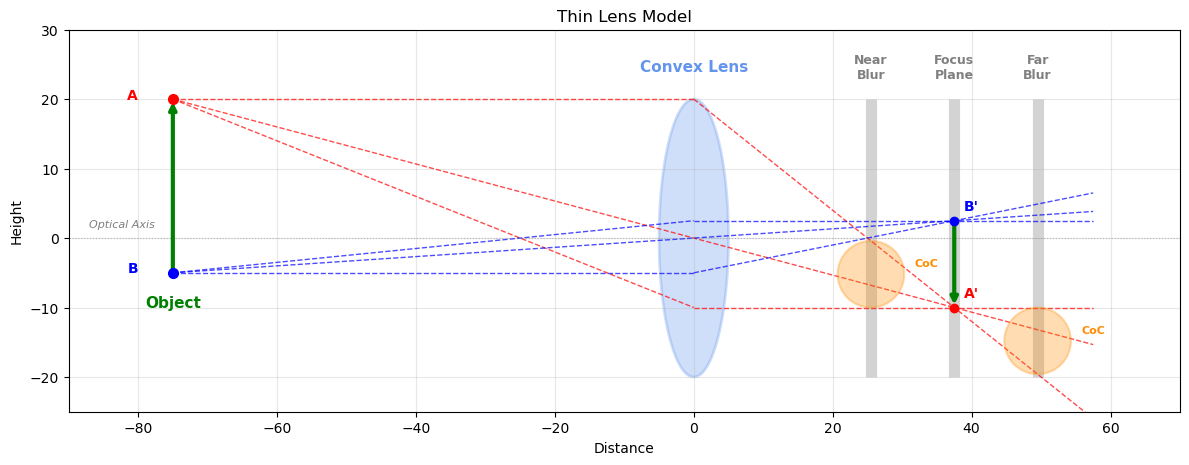

In [97]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_thin_lens_camera():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    lens_x, focal_length, lens_radius = 0, 25, 20
    object_x, object_height, object_base_y = -75, 25, -5
    
    do = abs(object_x - lens_x)
    di = (focal_length * do) / (do - focal_length)
    magnification = -di / do
    
    focused_sensor_x = lens_x + di
    near_sensor_x = focused_sensor_x - 12
    far_sensor_x = focused_sensor_x + 12
    
    arrow_tip_y = object_base_y + object_height
    arrow_base_y = object_base_y
    image_tip_y = arrow_tip_y * magnification
    image_base_y = arrow_base_y * magnification
    
    theta = np.linspace(-np.pi/2, np.pi/2, 100)
    lens_bulge = 5
    left_curve_x = lens_x - lens_bulge * np.cos(theta)
    right_curve_x = lens_x + lens_bulge * np.cos(theta)
    curve_y = lens_radius * np.sin(theta)
    ax.fill(np.concatenate([left_curve_x, right_curve_x[::-1]]),
            np.concatenate([curve_y, curve_y[::-1]]),
            color='cornflowerblue', alpha=0.3, edgecolor='cornflowerblue', linewidth=2)
    ax.text(lens_x, lens_radius + 4, 'Convex Lens', ha='center', fontsize=11, fontweight='bold', color='cornflowerblue')
    
    ax.annotate('', xy=(object_x, arrow_tip_y), xytext=(object_x, arrow_base_y),
                arrowprops=dict(arrowstyle='->', color='green', lw=3))
    ax.plot([object_x], [arrow_base_y], 'o', color='green', markersize=6)
    ax.text(object_x, arrow_base_y - 5, 'Object', ha='center', fontsize=11, fontweight='bold', color='green')
    ax.plot(object_x, arrow_tip_y, 'o', color='red', markersize=7, zorder=5)
    ax.plot(object_x, arrow_base_y, 'o', color='blue', markersize=7, zorder=5)
    ax.text(object_x - 5, arrow_tip_y, 'A', fontsize=10, ha='right', color='red', fontweight='bold')
    ax.text(object_x - 5, arrow_base_y, 'B', fontsize=10, ha='right', color='blue', fontweight='bold')
    
    def get_ray_heights(obj_y, x_pos):
        img_y = obj_y * magnification
        y1 = obj_y if x_pos <= lens_x else obj_y + (img_y - obj_y) * (x_pos - lens_x) / di
        y2 = obj_y * x_pos / object_x
        slope_to_F = -obj_y / (-focal_length - object_x)
        y_at_lens = obj_y + slope_to_F * (lens_x - object_x)
        y3 = obj_y + slope_to_F * (x_pos - object_x) if x_pos <= lens_x else y_at_lens
        return y1, y2, y3, y_at_lens
    
    x_end = far_sensor_x + 8
    
    for obj_y, color in [(arrow_tip_y, 'r'), (arrow_base_y, 'b')]:
        _, _, _, y_at_lens = get_ray_heights(obj_y, lens_x)
        y1_end, y2_end, _, _ = get_ray_heights(obj_y, x_end)
        
        ax.plot([object_x, lens_x], [obj_y, obj_y], f'{color}--', linewidth=1, alpha=0.7)
        ax.plot([lens_x, x_end], [obj_y, y1_end], f'{color}--', linewidth=1, alpha=0.7)
        ax.plot([object_x, x_end], [obj_y, y2_end], f'{color}--', linewidth=1, alpha=0.7)
        ax.plot([object_x, lens_x], [obj_y, y_at_lens], f'{color}--', linewidth=1, alpha=0.7)
        ax.plot([lens_x, x_end], [y_at_lens, y_at_lens], f'{color}--', linewidth=1, alpha=0.7)
    
    ax.plot(focused_sensor_x, image_tip_y, 'o', color='red', markersize=6, zorder=15)
    ax.plot(focused_sensor_x, image_base_y, 'o', color='blue', markersize=6, zorder=15)
    ax.text(focused_sensor_x + 3.5, image_tip_y + 1.5, "A'", fontsize=10, ha='right', color='red', fontweight='bold')
    ax.text(focused_sensor_x + 3.5, image_base_y + 1.5, "B'", fontsize=10, ha='right', color='blue', fontweight='bold')
    
    for sx, label in [(near_sensor_x, 'Near\nBlur'), (focused_sensor_x, 'Focus\nPlane'), (far_sensor_x, 'Far\nBlur')]:
        ax.plot([sx, sx], [-20, 20], color='lightgray', linewidth=8, solid_capstyle='butt', zorder=1)
        ax.text(sx, 23, label, ha='center', fontsize=9, color='gray', fontweight='bold')
        
        if abs(sx - focused_sensor_x) > 0.5:
            y1, y2, y3, _ = get_ray_heights(arrow_tip_y, sx)
            y_min, y_max = min(y1, y2, y3), max(y1, y2, y3)
            coc_radius = (y_max - y_min) / 2
            coc_center = (y_max + y_min) / 2
            ax.add_patch(patches.Circle((sx, coc_center), coc_radius, fill=True, facecolor='darkorange',
                                        alpha=0.3, edgecolor='darkorange', linewidth=1.5, zorder=10))
            ax.text(sx + coc_radius + 1.5, coc_center + 1.5, 'CoC', fontsize=8, color='darkorange', va='center', fontweight='bold')
    
    ax.annotate('', xy=(focused_sensor_x, image_tip_y), xytext=(focused_sensor_x, image_base_y),
                arrowprops=dict(arrowstyle='->', color='green', lw=3), zorder=10)
    ax.plot([focused_sensor_x], [image_base_y], 'o', color='green', markersize=5, zorder=10)
    
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(-87, 1.5, 'Optical Axis', fontsize=8, color='gray', style='italic')
    
    ax.set_title('Thin Lens Model')
    ax.set_xlim(-90, 70)
    ax.set_ylim(-25, 30)
    ax.set_aspect('equal')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Height')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(f"{output_folder_path}/thin_lens_model.svg", format='svg', bbox_inches='tight')
    plt.show()
    return fig

fig = plot_thin_lens_camera()

## Chromatic Aberration Plot

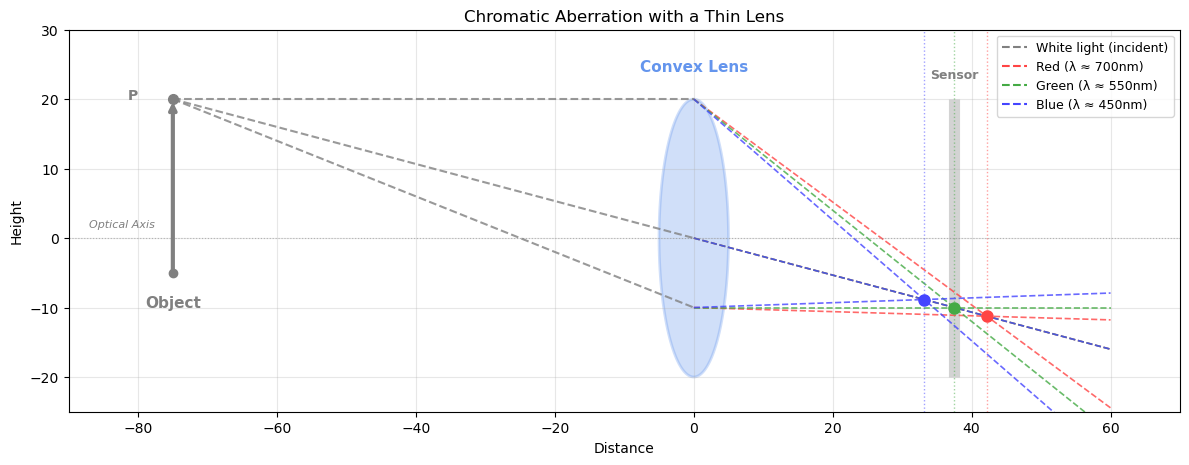

In [101]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_chromatic_aberration():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    lens_x, lens_radius = 0, 20
    object_x, object_height, object_base_y = -75, 25, -5
    focal_red, focal_green, focal_blue = 27, 25, 23
    
    arrow_tip_y = object_base_y + object_height
    do = abs(object_x - lens_x)
    x_end = 60
    
    theta = np.linspace(-np.pi/2, np.pi/2, 100)
    lens_bulge = 5
    left_curve_x = lens_x - lens_bulge * np.cos(theta)
    right_curve_x = lens_x + lens_bulge * np.cos(theta)
    curve_y = lens_radius * np.sin(theta)
    ax.fill(np.concatenate([left_curve_x, right_curve_x[::-1]]),
            np.concatenate([curve_y, curve_y[::-1]]),
            color='cornflowerblue', alpha=0.3, edgecolor='cornflowerblue', linewidth=2)
    ax.text(lens_x, lens_radius + 4, 'Convex Lens', ha='center', fontsize=11, fontweight='bold', color='cornflowerblue')
    
    ax.annotate('', xy=(object_x, arrow_tip_y), xytext=(object_x, object_base_y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=3))
    ax.plot([object_x], [object_base_y], 'o', color='gray', markersize=6)
    ax.text(object_x, object_base_y - 5, 'Object', ha='center', fontsize=11, fontweight='bold', color='gray')
    ax.plot(object_x, arrow_tip_y, 'o', color='gray', markersize=7, zorder=5)
    ax.text(object_x - 5, arrow_tip_y, 'P', fontsize=10, ha='right', color='gray', fontweight='bold')
    
    wavelengths = [('red', focal_red, '#ff4444'), ('green', focal_green, '#44aa44'), ('blue', focal_blue, '#4444ff')]
    
    ray1_lens_y = arrow_tip_y
    ray2_lens_y = 0
    slope_to_F_green = -arrow_tip_y / (-focal_green - object_x)
    ray3_lens_y = arrow_tip_y + slope_to_F_green * (lens_x - object_x)
    
    ax.plot([object_x, lens_x], [arrow_tip_y, ray1_lens_y], color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.plot([object_x, lens_x], [arrow_tip_y, ray2_lens_y], color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.plot([object_x, lens_x], [arrow_tip_y, ray3_lens_y], color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    
    for name, f, color in wavelengths:
        di = (f * do) / (do - f)
        img_y = arrow_tip_y * (-di / do)
        
        slope1 = (img_y - ray1_lens_y) / di
        ax.plot([lens_x, x_end], [ray1_lens_y, ray1_lens_y + slope1 * (x_end - lens_x)], color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        
        slope2 = (ray2_lens_y - arrow_tip_y) / (lens_x - object_x)
        ax.plot([lens_x, x_end], [ray2_lens_y, ray2_lens_y + slope2 * (x_end - lens_x)], color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        
        slope3 = (img_y - ray3_lens_y) / di
        ax.plot([lens_x, x_end], [ray3_lens_y, ray3_lens_y + slope3 * (x_end - lens_x)], color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        
        ax.plot(lens_x + di, img_y, 'o', color=color, markersize=8, zorder=15)
        ax.axvline(x=lens_x + di, color=color, linestyle=':', linewidth=1, alpha=0.5)
    
    di_green = (focal_green * do) / (do - focal_green)
    ax.plot([lens_x + di_green, lens_x + di_green], [-20, 20], color='lightgray', linewidth=8, solid_capstyle='butt', zorder=1)
    ax.text(lens_x + di_green, 23, 'Sensor', ha='center', fontsize=9, color='gray', fontweight='bold')
    
    legend_elements = [
        plt.Line2D([0], [0], color='gray', linestyle='--', label='White light (incident)'),
        plt.Line2D([0], [0], color='#ff4444', linestyle='--', label='Red (λ ≈ 700nm)'),
        plt.Line2D([0], [0], color='#44aa44', linestyle='--', label='Green (λ ≈ 550nm)'),
        plt.Line2D([0], [0], color='#4444ff', linestyle='--', label='Blue (λ ≈ 450nm)'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(-87, 1.5, 'Optical Axis', fontsize=8, color='gray', style='italic')
    
    ax.set_title('Chromatic Aberration with a Thin Lens')
    ax.set_xlim(-90, 70)
    ax.set_ylim(-25, 30)
    ax.set_aspect('equal')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Height')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(f"{output_folder_path}/chromatic_aberration.svg", format='svg', bbox_inches='tight')
    plt.show()
    return fig

fig = plot_chromatic_aberration()